# <font color='black'> Регрессионный анализ социально-экономических процессов, 2026 - 2027 </font>
# <font color='black'>Практическое занятие 2 </font>

## <font color='black'>Модель множественной линейной регрессии. Модели с переменными взаимодействия </font>
На этом занятии мы продолжим работать с данными из статьи [Kalenborn C., Lessman C., 2013](https://yadi.sk/i/nlEQUoWKiqY0UA). Одна из частей анализа в данной статье выполнена на основе cross-section data (использованы усредненные данные за 2005 - 2010 гг.). Авторы изучают взаимосвязь уровня коррупции и демократии, предполагая, что ее характер зависит от значений показателя свободы прессы. Кратко о данных:
* cpi - уровень коррупции: Corruption Perception Index. Непрерывная шкала от 0 до 10, где 10 означает наиболее высокий уровень коррупции.
* dem - индекс демократии: Vanhanen’s democratization index. Непрерывная шкала от 0 до 100, где 100 означает максимальное значение уровня демократии.
* fp - свобода прессы: Freedom House. Приведен к непрерывной шкале от 0 до 100, где 100 - наиболее высокое значение свободы прессы.
* loggdppc - натуральный логарифм ВВП на душу населения. World Bank.
* stab - уровень политической стабильности. Индекс построен на основе показателей "Political Stability" и "Absence of Violence/Terrorism" из the Worldwide Governance Indicators. Непрерывная шкала от -2.5 до 2.5, где 2.5 соответствует наиболее высокому уровню политической стабильности.
* britcol - дамми-переменная, где 1 - бывшая британская колония.

In [15]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set(style = "white", palette='deep')

Откроем массив данных для репликации результатов исследования - lab1.dta.

In [16]:
lab2 = pd.read_stata('lab1.dta')
lab2 = lab2.dropna()

Познакомимся с тем, как устроен массив данных.

In [17]:
lab2.head(10)

,country,loggdppc,britcol,dem,stab,fp,cpi
0,Afghanistan,6.216606,0,10.766666,-2.495174,27.666666,7.733000
1,Albania,8.216088,0,24.666666,-0.243981,50.000000,6.449667
2,Algeria,8.427268,0,10.100000,-1.127764,37.833332,6.466333
4,Angola,8.371011,0,2.383333,-0.505494,37.166668,7.416333
6,Argentina,9.118225,0,28.466665,0.007387,51.666668,6.549666
7,Armenia,8.016318,0,22.616667,-0.009874,34.500000,6.599667
8,Australia,10.833681,1,31.350000,0.890034,79.000000,0.733000
9,Austria,10.712193,0,38.200001,1.165692,79.000000,1.216333
10,Azerbaijan,8.672486,0,12.033333,-0.626197,23.166666,7.216333
12,Bahrain,9.809176,0,1.133333,-0.220283,28.666666,4.116333


Оценим для начала регрессионную модель без переменных взаимодействия

In [18]:
m1 = smf.ols(formula = "cpi ~ dem + fp + loggdppc + britcol + stab", data = lab2).fit(cov_type = "HC3")
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     73.14
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           5.83e-40
Time:                        03:36:40   Log-Likelihood:                -249.04
No. Observations:                 170   AIC:                             510.1
Df Residuals:                     164   BIC:                             528.9
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.2657      0.653     18.781      0.0

Рассмотрим, как различается уровень коррупции в группах стран с разным уровнем свободы прессы. Предварительно разделим страны на 2 группы: "not free" и "free". В качестве порогового значения для разделения возьмем 70 баллов по показателю "свобода прессы".

In [19]:
lab2['groups'] = lab2['fp'].apply(lambda x: 1 if x > 70 else 0)

Модель 2 включает вместо непрерывной переменной уровня свободы прессы бинарный показатель "groups" в качестве предиктора. Проинтерпретируйте оценки коэффициентов модели m2.

In [20]:
m2 = smf.ols(formula = "cpi ~ dem + groups + loggdppc + britcol + stab", data = lab2).fit(cov_type = "HC3")
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     80.61
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.29e-42
Time:                        03:36:40   Log-Likelihood:                -247.44
No. Observations:                 170   AIC:                             506.9
Df Residuals:                     164   BIC:                             525.7
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.3631      0.631     17.995      0.0

Тем не менее, данная модель не позволяет ответить на ключевой вопрос, которые ставили перед собой Kalenborn C., Lessman C. А именно, их интересовало, различается ли взаимосвязь коррупции и уровня демократии в странах с разными значениями свободы прессы? Для того, чтобы продвинуться в ответе на данный вопрос, представим следующий график. Какой предварительный вывод Вы можете сделать на основе данного графика?  

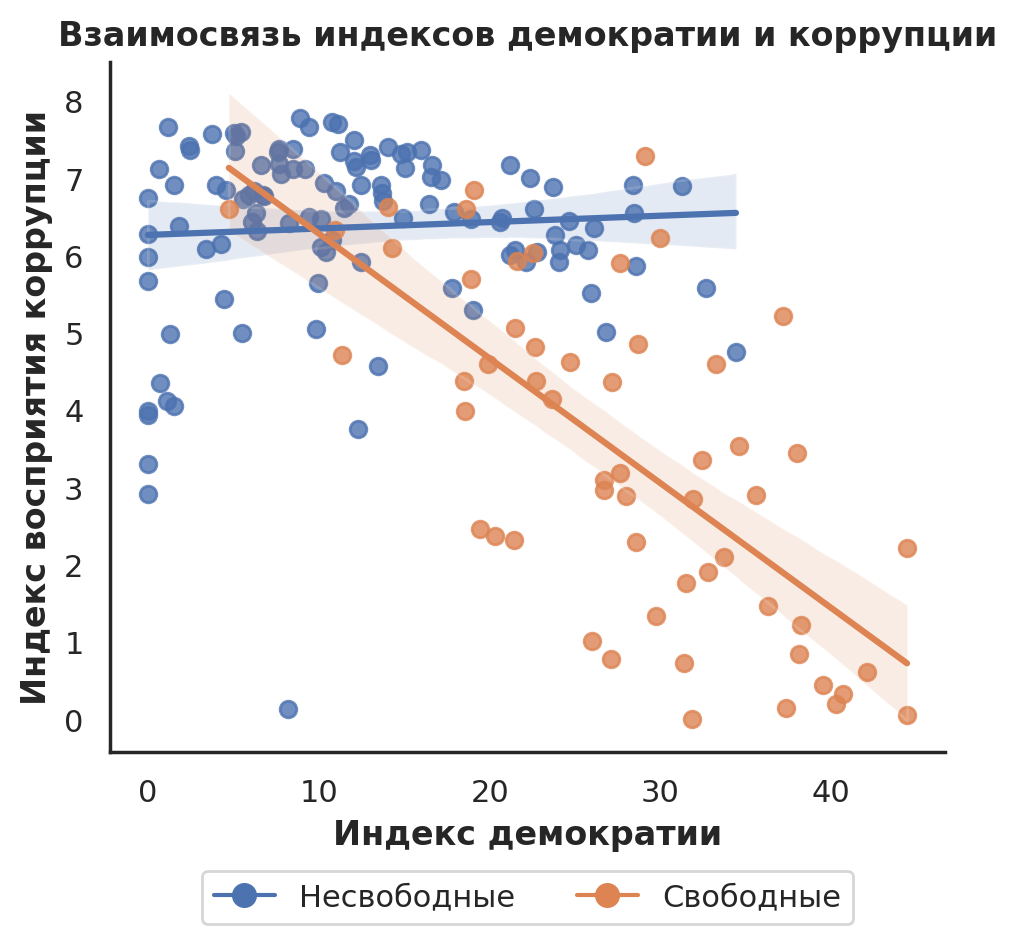

In [21]:
fig = sns.lmplot(data=lab2, x="dem", y="cpi", hue="groups", legend=False)

plt.title("Взаимосвязь индексов демократии и коррупции", fontweight='bold')
plt.xlabel("Индекс демократии", fontweight='bold')
plt.ylabel("Индекс восприятия коррупции", fontweight='bold')

palette = sns.color_palette('deep', 2)
legend_elements = [
    mlines.Line2D([], [], color=palette[0], marker='o',
                 markersize=8, label='Несвободные'),
    mlines.Line2D([], [], color=palette[1], marker='o',
                 markersize=8, label='Свободные')
]

plt.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Изменим спецификацию регрессионной модели так, чтобы она позволяла ответить на вопрос, как различается взаимосвязь коррупции и уровня демократии в двух группах стран (условно назовем их "свободные" и "несвободные"). Для этого нужно ввести переменную взаимодействия между предиктором "dem" и "groups".
Проинтерпретируйте оценки коэффициентов в модели m3.

In [22]:
m3 = smf.ols(formula = "cpi ~ dem*groups + loggdppc + britcol + stab", data = lab2).fit(cov_type = "HC3")
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     93.94
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.61e-50
Time:                        03:36:41   Log-Likelihood:                -230.49
No. Observations:                 170   AIC:                             475.0
Df Residuals:                     163   BIC:                             496.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0227      0.623     16.098      0.0

Проиллюстрируем на графике различия между предельными эффектами демократии в зависимости от групп стран. Для этого нам предварительно понадобится
* задать формулу для расчета предельных эффектов. Для этого мы

1) извлечем оценки коэффициентов модели m3 (marg_effect)

2) получим вектор уникальных значений переменной "groups" (values), которая является условием (то есть, от ее значений зависит предельный эффект демократии)

* задать формулу для расчета стандартных ошибок

In [23]:
print(m3.params)
print(m3.cov_params())

Intercept     10.022696
dem            0.013517
groups         1.554287
dem:groups    -0.112651
loggdppc      -0.514086
britcol       -0.427492
stab          -0.583726
dtype: float64
            Intercept       dem    groups  dem:groups  loggdppc   britcol  \
Intercept    0.387640  0.000940 -0.058868    0.004455 -0.049278 -0.051549   
dem          0.000940  0.000064  0.000764   -0.000028 -0.000270  0.000083   
groups      -0.058868  0.000764  0.270321   -0.008902  0.004578 -0.008711   
dem:groups   0.004455 -0.000028 -0.008902    0.000373 -0.000501 -0.000159   
loggdppc    -0.049278 -0.000270  0.004578   -0.000501  0.006750  0.005651   
britcol     -0.051549  0.000083 -0.008711   -0.000159  0.005651  0.044302   
stab         0.021911 -0.000120 -0.014899    0.000206 -0.001804  0.002989   

                stab  
Intercept   0.021911  
dem        -0.000120  
groups     -0.014899  
dem:groups  0.000206  
loggdppc   -0.001804  
britcol     0.002989  
stab        0.011240  


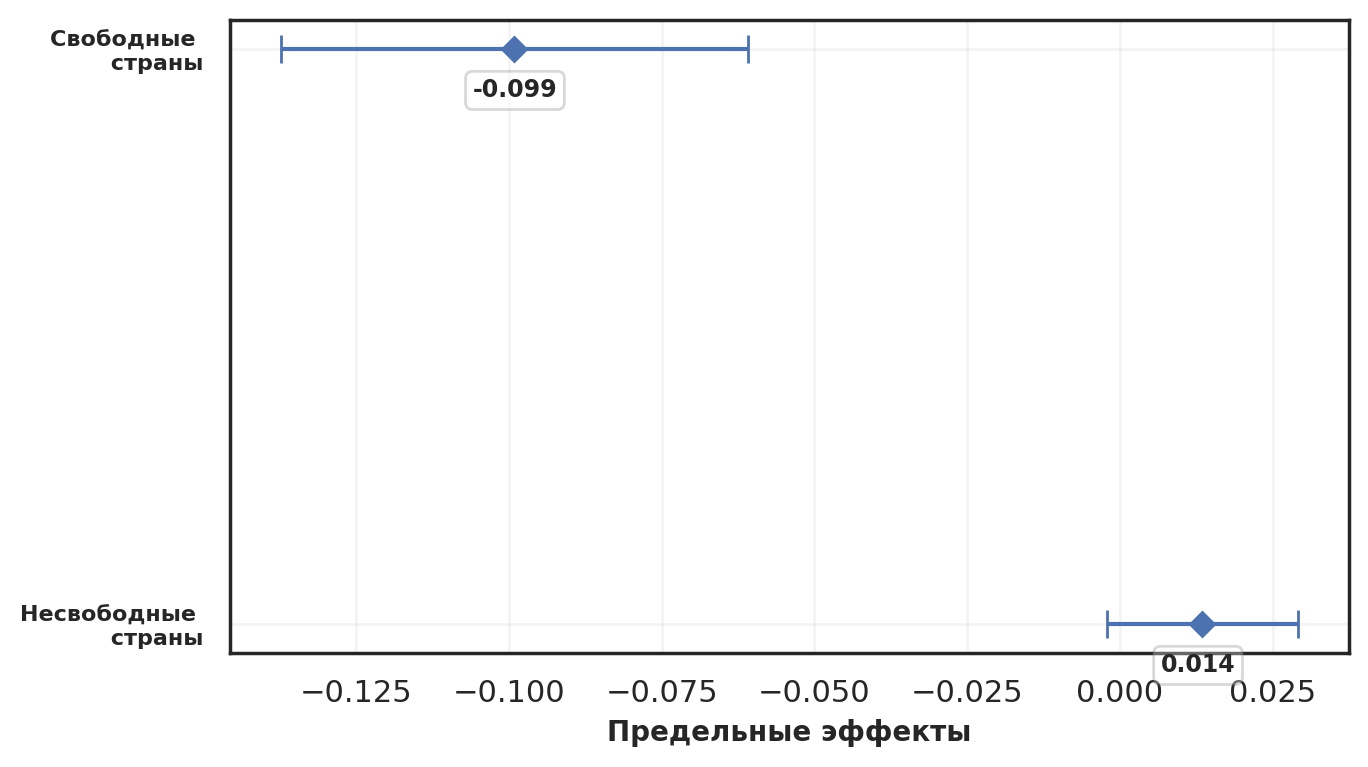

In [24]:
v = lab2.groups.unique()
me = m3.params.iloc[1] + m3.params.iloc[3] * v
cov = m3.cov_params().values
se = np.sqrt(cov[1,1] + v**2 * cov[3,3] + 2 * v * cov[1,3])

plt.figure(figsize=(7, 4))
plt.errorbar(me, v, xerr=1.96 * se, fmt='D', capsize=5)

plt.yticks([0, 1], ['Несвободные \n страны', 'Свободные \n страны'],
           fontsize=8, fontweight='bold')

for i, (y_val, x_val) in enumerate(zip(v, me)):
    plt.annotate(f'{x_val:.3f}', (x_val, y_val), xytext=(-15, -15),
                textcoords='offset points', va='center',
                fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.3, edgecolor='gray'))

plt.xlabel('Предельные эффекты', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Теперь попробуем оценить модель, но уже с переменной взаимодействия между исходными непрерывными переменными "dem" и "fp", без деления стран на группы "not free" и "free". Какой вывод можно сделать на основе оценок данной модели?
Предложите возможные преобразования для более удобной интерпретации и примените их при оценивании модели (в качестве дополнительной практики после занятия).

In [25]:
m4 = smf.ols(formula = "cpi ~ dem*fp + loggdppc + britcol + stab", data = lab2).fit(cov_type = "HC3")
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     110.1
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.02e-54
Time:                        03:36:41   Log-Likelihood:                -227.22
No. Observations:                 170   AIC:                             468.4
Df Residuals:                     163   BIC:                             490.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.5637      0.739     12.941      0.0

Покажем на графике, как изменяется предельный эффект демократии и его значимость в зависимости от "условия" (freedom of press). Проинтерпретируйте график.

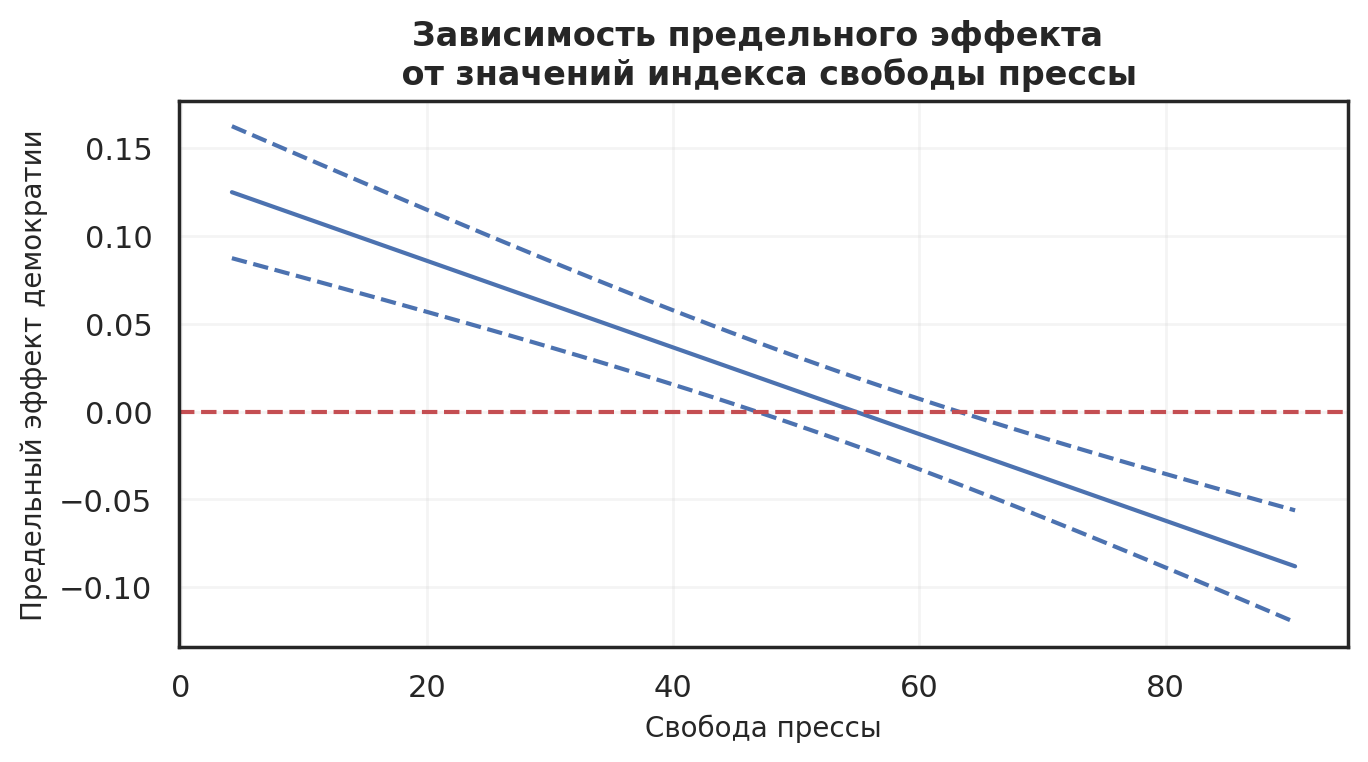

In [26]:
cov_m4 = np.asarray(m4.cov_params())
fp_values = np.linspace(lab2.fp.min(), lab2.fp.max())
marg_effect_m4 = m4.params.iloc[1] + m4.params.iloc[3]*fp_values
se2 = np.sqrt(cov_m4[1,1] + fp_values**2*(cov_m4[3,3]) + 2*fp_values*cov_m4[1,3])

plt.figure(figsize=(7, 4))
plt.plot(fp_values, marg_effect_m4, 'b')
plt.plot(fp_values, marg_effect_m4 - norm.ppf(0.975)*se2, 'b--')
plt.plot(fp_values, marg_effect_m4 + norm.ppf(0.975)*se2, 'b--')
plt.xlabel('Свобода прессы', fontsize=10)
plt.ylabel('Предельный эффект демократии', fontsize=10)
plt.axhline(y=0, color ='r', linestyle = '--')
plt.title('Зависимость предельного эффекта \n от значений индекса свободы прессы', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Резюмируйте результаты проведенного анализа.